# IMPORT PACKAGES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import fdrcorrection
import matplotlib_venn
from venny4py.venny4py import *
from scipy import stats
import math
from matplotlib.lines import Line2D
from matplotlib.text import Text
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler
import lightgbm as lgb
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pickle
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import matplotlib
import random
import unicodeit
from matplotlib.colors import LinearSegmentedColormap
import umap
from sklearn.manifold import TSNE

In [2]:
from scipy.stats import entropy

# SELECT HEALTHY

In [1]:
# metadata=pd.read_excel('HNG.xlsx',sheet_name='QC V1')
# metadata

In [3]:
# Cancer=metadata[metadata['Type']=='Gastric']
# Cancer

In [4]:
# Healthy=metadata[metadata['Type']=='Healthy']
# Healthy

In [5]:
# # def Select_healthy(Cancer,Healthy,n=2,col_cohort='SMBM5_Cohort'): 
# n=2
# col_cohort='Cohort'
# for i in range(n):  
#         for s in list(Cancer['SampleID']):
#                 df=Cancer[Cancer['SampleID']==s]
#                 age=list(df['Age'])[0]
#                 gender=list(df['Gender'])[0]
#                 # run=list(df['R'])[0]
#                 cohort=list(df[col_cohort])[0]

#                 dfh=Healthy[(Healthy['Gender']==gender)&(Healthy[col_cohort]!='Discovery')&(Healthy[col_cohort]!='Unseen')]#&(Healthy['Rerun']=='No')
#                 dfh['gap_age']=dfh.apply(lambda r: abs(r['Age']-age),axis=1)
#                 # dfh['gap_run']=dfh.apply(lambda r: abs(r['R']-run),axis=1)
#                 # dfh1=dfh[dfh['gap_age']<=5]
#                 gap_age1=[]
#                 for gap in list(dfh['gap_age']):
#                         if gap <= 3:
#                                 gap_age1+=[0]
#                         elif gap <= 6:
#                                 gap_age1 +=[1]
#                         elif gap <= 10:
#                                 gap_age1 +=[2]
#                         else:
#                                 gap_age1+=[3]
#                 dfh['gap_age1']=gap_age1
#                 # dfh.sort_values(by=['gap_age1','gap_run','gap_age'],inplace=True)
#                 dfh.sort_values(by=['gap_age1','gap_age'],inplace=True)
#                 ind=dfh.index[0]
#                 Healthy.loc[ind,col_cohort]=cohort
#                 Healthy.loc[ind,'Pair']=s
# Healthy

In [6]:
# Healthy=Healthy[Healthy['Cohort']=='Discovery']
# Healthy

In [7]:
# Healthy.to_clipboard(index=False)

# DEFINE FUNCTION

In [3]:
#Hàm wilcoxon mới
def STATS_binary(df_1,df_2,col_start,name_1,name_2,groups_PADJ=[]):
    # import pandas as pd
    # import numpy as np
    # from statsmodels.stats.multitest import fdrcorrection
    # from scipy import stats
    # import math
    Mean_1,Mean_2,Median_1,Median_2,Feature,P_value,AUC,Log2FC, Log2FC_Median=[],[],[],[],[],[],[],[],[]
    SD_1,SD_2,CVpct_1,CVpct_2=[],[],[],[]
    for i in range(col_start,df_1.shape[1]):
        #Mean
        m1=np.mean(list(df_1.iloc[:,i]))
        m2=np.mean(list(df_2.iloc[:,i]))
        Mean_1+=[m1]
        Mean_2+=[m2]
        #Median
        me1=np.median(list(df_1.iloc[:,i]))
        me2=np.median(list(df_2.iloc[:,i]))
        Median_1+=[me1]
        Median_2+=[me2]
        #P-value
        P_value+=[stats.ranksums(df_1.iloc[:,i],df_2.iloc[:,i])[1]]
        #Log2FC
        if m1 !=0 and m2 !=0:
            Log2FC+=[math.log2(abs(m2/m1))]
        else:
            Log2FC+=[0]

        if me1 !=0 and me2 !=0:
            Log2FC_Median+=[math.log2(abs(me2/me1))]
        else:
            Log2FC_Median+=[0]
        #Features
        Feature+=[df_1.columns[i]]
        #AUC
        AUC+=[metrics.roc_auc_score([0]*len(df_1)+[1]*len(df_2), list(df_1.iloc[:,i])+list(df_2.iloc[:,i]))]
        #SD and CV%
        sd1=np.std(list(df_1.iloc[:,i]))
        sd2=np.std(list(df_2.iloc[:,i]))
        SD_1+=[sd1]
        SD_2+=[sd2]
        if m1 != 0:
            CVpct_1+=[sd1/m1*100]
        else: 
            CVpct_1+=[np.NaN]
        if m2 != 0:
            CVpct_2+=[sd2/m2*100]
        else: 
            CVpct_2+=[np.NaN]
    else:
        result=pd.DataFrame({'FEATURES':Feature,
                             'Mean of '+name_1:Mean_1,
                             'Mean of '+name_2:Mean_2,
                             'Median of '+name_1:Median_1,
                             'Median of '+name_2:Median_2,
                             'SD of '+name_1:SD_1,
                             'SD of '+name_2:SD_2,
                             'CV% of '+name_1:CVpct_1,
                             'CV% of '+name_2:CVpct_2,
                             'Log2FC of '+name_1+' vs '+name_2:Log2FC,
                             'Log2FC Median of '+name_1+' vs '+name_2:Log2FC_Median,
                             'P of '+name_1+' vs '+name_2:P_value})
        #Adjust p-value
        PADJ=[]
        for g in groups_PADJ:
            filtered_result=result[result['FEATURES'].str.startswith(g)]
            if len(filtered_result)>0:
                PADJ+=list(fdrcorrection(filtered_result['P of '+name_1+' vs '+name_2])[1])
            else:
                PADJ+=[] 
        result['PADJ of '+name_1+' vs '+name_2]=PADJ
        result['Round_Mean of '+name_1]=result.apply(lambda row: round(row['Mean of '+name_1],2),axis=1)
        result['Round_Mean of '+name_2]=result.apply(lambda row: round(row['Mean of '+name_2],2),axis=1)
        result['-log10(p-value) of '+name_1+' vs '+name_2]=result.apply(lambda row: -math.log10(row['PADJ of '+name_1+' vs '+name_2]),axis=1)
        result['Distance of '+name_1+' vs '+name_2]=result.apply(lambda row: row['Mean of '+name_2]-row['Mean of '+name_1],axis=1)
        result['AUC of '+name_1+' vs '+name_2]=AUC
        result['AUCADJ of '+name_1+' vs '+name_2]=result.apply(lambda row: row['AUC of '+name_1+' vs '+name_2] if row['Log2FC of '+name_1+' vs '+name_2]>=0 else 1-row['AUC of '+name_1+' vs '+name_2],axis=1)
    return result
def STATS_features(df,pair,groups_PADJ=[],col_start=5):
    # import pandas as pd

    Gastric=df[df['Type']=='Gastric']
    Healthy=df[df['Type']=='Healthy']

    Group={'Gastric':Gastric,
           'Healthy':Healthy
           }
    result=pd.DataFrame()
    for p in pair:
        name_1=p.split(' vs ')[0]
        name_2=p.split(' vs ')[1]
        stats_bi=STATS_binary(df_1=Group[name_1],df_2=Group[name_2],col_start=col_start,name_1=name_1,name_2=name_2,groups_PADJ=groups_PADJ)
        result=pd.concat([result,stats_bi],axis=1)
    else:
        result = result.loc[:,~result.columns.duplicated()].copy()
    return result

def introundup(a):
    import math
    b=math.ceil(a)
    c=len(str(b))
    d=pow(10,c-1)
    e=a/d
    f=math.ceil(e)
    g=f*d
    return g
def features_include(features,lst_fea,fsm,f_group):
    df=pd.DataFrame({'FEATURES':list(lst_fea)})
    Number=[]
    for f in features:
        Number+=[len(df[df['FEATURES'].str.startswith(f)])]
    fea_include=pd.DataFrame({'FEATURES':features,fsm+' | '+f_group:Number})
    return fea_include

## Heatmapfea

In [4]:
#Heatmap các features
def heatmapfea(f='TMD'):
# TMD
# GWMD
# CNA
# flen
# MOTIF_END
# GWFP_long
# GWFP_short
# GWFP_total
# GWFP_ratio
    
    custom_lines = [
                    Line2D([0], [0], color='b', lw=4),
                    # Line2D([0], [0], color='g', lw=4),
                    # Line2D([0], [0], color='goldenrod', lw=4),
                    Line2D([0], [0], color='r', lw=4),
                    ]
    regex='Class|'+f
    data_f = fea[f].filter(regex=(regex)).sort_values(by='Class')
    # dict of {cat: color}
    # Type=['Healthy','Gastritis','Precancerous','Gastric_cancer']
    Type=['Healthy','Gastric']
    # lut = dict(zip(Type, ['b','g','goldenrod','r']))
    lut = dict(zip(Type, ['b','r']))
    # corresponding color per column
    col_colors = fea[f].Type.map(lut)
    ax=sb.clustermap(
        # try to sort by species and transpose dataframe
        data=data_f.drop(columns='Class').T,
        figsize=(15, 5),
        metric='correlation',
        standard_scale=0,
        cmap='viridis',
        col_cluster=False,
        xticklabels=True,
        yticklabels=False,
        row_cluster=True,
        dendrogram_ratio=(.1, .2), cbar_pos=(1.01, .1, .03, .4),
        col_colors=col_colors,
    )
    ax.fig.suptitle(f,fontsize=40)
    plt.legend(custom_lines,Type,bbox_to_anchor=(0,1.2), loc="lower left")
    plt.show()

## Volcanofea

In [5]:
def volcanofea(f,pair=['Healthy vs Gastric'],alpha=0.05,show_region=False):
    data=stats_fea[f]
    data.index=data.FEATURES
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        col_log='Log2FC of '+p
        col_PADJ='-log10(p-value) of '+p
        cols=[]
        for r in data['FEATURES']:
            if data.loc[r,'PADJ of '+p] >=alpha:
                cols+=['gray']
            elif data.loc[r,'PADJ of '+p] < alpha:
                if data.loc[r,col_log] >= 0:
                    cols+=['r']
                else:
                    cols+=['b']
        plt.figure(figsize=(6,6))
        x=data[col_log]
        y=data[col_PADJ]
        sb.scatterplot(x=x,y=y,c=cols,linewidth=0.5,edgecolor='black')
        plt.axvline(x=0, color='gray', label='axvline - full height',ls='--')
        left, right = plt.xlim()
        plt.axhline(y=-math.log10(alpha), color='green', label='axhline - full height',ls='--')
        plt.xlabel(u'log\u2082(fold change of means '+p.split(' vs ')[1]+'/'+ p.split(' vs ')[0]+')')
        plt.ylabel(unicodeit.replace('-log_1_0(adjusted p-value)'))
        plt.title('Volcano plot - '+f+' - '+p)
        # plt.yticks(np.arange(0,8,1))
        # plt.xticks(np.arange(-0.1,0.4,0.1))
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.2))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        lst_name_show=list(data[((data[col_log]<=-0.1)|(data[col_log]>=0.015))]['FEATURES'])
        if show_region:
            region_name = list(data['FEATURES'])
            for i, txt in enumerate(region_name):
                if txt in lst_name_show:
                    plt.text(x[i],y[i],txt,fontsize=8,color='red')

## AUCplotfea

In [6]:
def AUCplotfea(f,pair=['Gastric vs Healthy'],alpha=0.05): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES','PADJ of '+p,'Log2FC of '+p,'AUCADJ of '+p]]
        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL' or f=='TMD':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        plt.figure(figsize=(10,5))
        sb.scatterplot(data=df,x=x,y=list(df['AUCADJ of '+p]),c=cols)
        plt.yticks(np.arange(0.3,1.05,0.05))
        plt.xticks([])
        plt.xlabel('Regions')
        plt.ylabel('AUC')
        plt.title('AUC of '+f+' features - '+p)
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.5))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

## Variability

In [7]:
def Varplotfea(f,pair=['Gastric vs Healthy'],sig=False,alpha=0.05,VAR='AUC',ytick=[0,110,10],fea_compare='TMD',show_region=False,region_to_show=[]): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES',
                        'PADJ of '+p,
                        'Log2FC of '+p,
                        'AUCADJ of '+p,
                        # 'CV% of Healthy',
                        # 'Entropy of Healthy',
                        'CV% of '+p.split(' vs ')[0],
                        'CV% of '+p.split(' vs ')[1],
                        'Entropy of '+p.split(' vs ')[0],
                        'Entropy of '+p.split(' vs ')[1],                        
                        ]]
        df.fillna(0,inplace=True)
        mean_=[np.mean(list(df[VAR+' of '+p.split(' vs ')[0]])),np.mean(list(df[VAR+' of '+p.split(' vs ')[1]]))]
        if sig:
            df=df[df['PADJ of '+p]<alpha]          

        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        elif f in ['TM_CNA','TM_flen','TM_EM']:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        elif f =='GWMD' or f=='CNA':
            x=[i for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[1] for i in list(df['FEATURES'])]

        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        
        if VAR == 'AUC':
            plt.figure(figsize=(10,5))
            sb.scatterplot(data=df,x=x,y=list(df[VAR+'ADJ of '+p]),c=cols)
            plt.yticks(np.arange(0.3,1.05,0.05))
            plt.xticks([])
            plt.xlabel('Regions (features)')
            plt.ylabel(VAR)
            plt.title(VAR+' of '+f+' features - '+p)
        else:
            for i in [0,1]:
                plt.figure(figsize=(10,5))
                y=list(df[VAR+' of '+p.split(' vs ')[i]])
                sb.scatterplot(data=df,x=x,y=y,c=cols,markers='.')
                # plt.axhline(y=np.mean(list(df[VAR+' of Healthy'])), color='magenta', label='axvline - full height',ls='--')
                # plt.axhline(y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), color='red', label='axvline - full height',ls='--')
                plt.axhline(y=mean_[i], color='black', label='axvline - full height',ls='--')
                # plt.text(x=len(x)*1.06, y=np.mean(list(df[VAR+' of Healthy']))+ytick[2]/10, s='Average in Healthy', fontsize=12,color='magenta')
                # plt.text(x=len(x)*1.06, y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), s='Average in '+fea_compare+' of '+p.split(' vs ')[i], fontsize=12,color='red')
                plt.text(x=len(x)*1.06, y=mean_[i]-ytick[2]/3, s='Average in '+p.split(' vs ')[i], fontsize=12)
                plt.yticks(np.arange(ytick[0],ytick[1],ytick[2]))
                plt.xticks([])
                plt.xlabel('Regions (features)')
                plt.ylabel(VAR)
                plt.title(VAR+' of '+f+' features - '+p.split(' vs ')[i])

                se_cols=pd.Series(cols)
                count=se_cols.value_counts()
                lst=[]
                for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
                    lst+=[i+' ('+str(count.get(j, 0))+')']
                plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                
                if show_region:
                    region_name = list(df['FEATURES'])
                    for i, txt in enumerate(region_name):
                        if txt in region_to_show:
                            plt.text(x[i],y[i],txt,fontsize=8,color='red')

        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

## PCAsigfea

In [8]:
def PCAsigfea(p='Healthy vs Gastric',f='TMD',
              sig=True,alpha=0.05,show_ID=False,IDs=[],
              plot_pct_explain=False,top_pc=2,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='PCA.png'
              ):   
    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
    else:
        df=fea[f]


    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]


    Group={'Gastric':Gastric,
        'Healthy':Healthy,
        }

    data_pair=pd.concat([Group[p.split(' vs ')[0]],Group[p.split(' vs ')[1]]],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    data_pair=pd.concat([Group[p.split(' vs ')[0]],Group[p.split(' vs ')[1]]],axis=0)
    data_pair.reset_index(drop=True,inplace=True)
        
    data=data_pair.drop(list(df.columns[0:col_start]),axis=1)
    pca=PCA(random_state=0)
    pca.fit(data)
    pca_data=pca.transform(data)

    # pca_data=pca.transform(scaled_data)

    per_var=np.round(pca.explained_variance_ratio_*100,decimals=1)
    labels=['PC'+str(x) for x in range(1,len(per_var)+1)]

    if plot_pct_explain ==True:
        if top_pc > df.shape[1]-col_start:
            top_pc = df.shape[1]-col_start
        ax1=plt.figure(figsize=(5,5))
        plt.bar(x=range(1,len(per_var[0:top_pc])+1),height=per_var[0:top_pc],tick_label=labels[0:top_pc])
        plt.ylabel('Percentage of Explained Variance')   
        plt.xlabel('Principal Component')
        if sig:
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:        
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+f,pad=20)
        plt.yticks(np.arange(0,110,top_pc))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        if save:
            plt.savefig(figname[0:len(figname)-4]+'_top10.png',dpi=600,bbox_inches='tight')
    
    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data_pair['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(pca_data[:,0][i], pca_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('PCA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('PCA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | '+p+' | '+f,pad=20)
    
    custom_lines = [
        Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
        # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
        # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                            ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


## LDAsigfea

In [9]:
def LDAbinary(pairs=['Healthy vs Gastric'],features=['TMD'],sig=True,alpha=0.05,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='LDA.png'
              ):
    for p in pairs:
        LDA_data=pd.DataFrame()
        for f in features:
            if sig:
                sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
                df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
            else:
                df=fea[f]

            if df.shape[1]<=col_start:
                df=fea[f]
                
            Healthy=df[df['Class']==0]
            Gastric=df[df['Class']==1]


            Group={'Gastric':Gastric,
                    'Healthy':Healthy,
                    }
            
            data_pair0=Group[p.split(' vs ')[0]]
            data_pair0.insert(loc=1,column='Group',value=0)
            data_pair1=Group[p.split(' vs ')[1]]
            data_pair1.insert(loc=1,column='Group',value=1)
            data_pair=pd.concat([data_pair0,data_pair1],axis=0)
            data_pair.reset_index(drop=True,inplace=True)
            # data_pair

            X=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
            y=data_pair['Group']

            lda=LDA()
            X_train = lda.fit_transform(X, y)

            lst=[]
            for i in range(len(X_train)):
                lst+=[X_train[i,0]]
            LDA_data[f]=list(lst)
            # else:
            LDA_data['Class']=y
            cols=[]
            for t in data_pair['Class']:
                if t == 0: cols+=['b']
                elif t == 1: cols+=['r']
                #Plot LDA
        plt.figure(figsize=(len(features)*3,5))
        ax=sb.swarmplot(data=LDA_data.melt(id_vars='Class'),x='variable',y='value',c=cols)
        custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=7),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7)
                            ]
        plt.legend(custom_lines,['Healthy','Gastric'],loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
        plt.xticks(ticks=[0],labels=['']
                   )
        plt.xlabel('')
        plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
        plt.ylabel('LD1')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.title('LDA | '+p+' | '+f,pad=20)
        if save:
            plt.savefig(figname,dpi=600,bbox_inches='tight')


## UMAPfea

In [10]:
def UMAPfea(f='EM',p='Healthy vs Gastric',
            yticks=[0,5,1],xticks=[0,5,1],
            n_neighbors=3,n_components=2,show_sample=False,region_to_show=[],
            save=False,figname='UMAP.png'
            ):
    df=fea[f]

    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]

    Group={'Gastric':Gastric,
            'Healthy':Healthy,
            }

    data_pair0=Group[p.split(' vs ')[0]]
    data_pair0.insert(loc=1,column='Group',value=0)
    data_pair1=Group[p.split(' vs ')[1]]
    data_pair1.insert(loc=1,column='Group',value=1)
    data_pair=pd.concat([data_pair0,data_pair1],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    data=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
    data_y=data_pair['Group']
    umap_model = umap.UMAP(n_neighbors=n_neighbors,n_components=n_components, random_state=42)
    X_umap = umap_model.fit_transform(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_umap[:, 0],y=X_umap[:, 1],c=cols)
    plt.title('UMAP | '+p+' | '+f+' | n_neighbors='+str(n_neighbors),pad=20)
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # plt.yticks(np.arange(0,9,1))
    # plt.xticks(np.arange(-6,18,2))

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))

    if show_sample:
        sample_name = list(data_pair['SampleID'])
        for i, txt in enumerate(sample_name):
            if txt in region_to_show:
                plt.text(X_umap[:, 0][i],X_umap[:, 1][i],txt,fontsize=8,color='red')

    custom_lines = [
            Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
            # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
            # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                                ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')

## TSMEfea

In [11]:
def TSNEfea(f='EM',
    p='Healthy vs Gastric',
    yticks=[0,5,1],
    xticks=[0,5,1],
    perplexity=30,
    save=False,
    figname='TSNE.png'):

    df=fea[f]

    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]

    Group={'Gastric':Gastric,
            'Healthy':Healthy,
            }

    data_pair0=Group[p.split(' vs ')[0]]
    data_pair0.insert(loc=1,column='Group',value=0)
    data_pair1=Group[p.split(' vs ')[1]]
    data_pair1.insert(loc=1,column='Group',value=1)
    data_pair=pd.concat([data_pair0,data_pair1],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    data=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
    data_y=data_pair['Group']

    tsne = TSNE(perplexity=perplexity,n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_tsne[:, 0],y=X_tsne[:, 1],c=cols)
    plt.title('t-SNE | '+p+' | '+f+' | '+str(perplexity),pad=20)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    custom_lines = [
                Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
                # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                                    ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


# EXPERIMENT ID

In [7]:
exp_id='HNG'

# LOAD DATA

In [8]:
metadata=pd.read_excel(exp_id+'.xlsx',sheet_name='QC V1')
# metadata=pd.read_excel(exp_id+'.xlsx',sheet_name='QC2')
metadata

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0,0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0,0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0,0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HNGH011,HNGH011,0,0,Healthy,0,53,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0,0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,HNGK095,HNGK095,1,4,Gastric,BV K,58,M,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111,HNGK096,HNGK096,1,4,Gastric,BV K,50,M,IIIA,III,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,HNGK101,HNGK101,1,4,Gastric,BV K,61,F,IIIA,IIIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,HNGK102,HNGK102,1,4,Gastric,BV K,68,F,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#Data QC
data_qc=metadata[(metadata['Cohort']=='Discovery')|(metadata['Cohort']=='Unseen')|(metadata['Cohort']=='STD')]
# data_qc[['Gender']] = data_qc[['Gender']].replace(['F','M'], [0,1])
# data_qc=pd.concat([Cancer,Healthy],axis=0)
data_qc

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0,0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0,0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0,0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HNGH011,HNGH011,0,0,Healthy,0,53,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0,0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,HNGK095,HNGK095,1,4,Gastric,BV K,58,M,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111,HNGK096,HNGK096,1,4,Gastric,BV K,50,M,IIIA,III,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,HNGK101,HNGK101,1,4,Gastric,BV K,61,F,IIIA,IIIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,HNGK102,HNGK102,1,4,Gastric,BV K,68,F,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
data_qc[['Cohort','Type']].value_counts().sort_index()

Cohort     Type   
Discovery  Gastric    60
           Healthy    55
Name: count, dtype: int64

## Get data_qc_Discovery

In [16]:
data_qc_Discovery=data_qc[(data_qc['Cohort']=='Discovery')]
data_qc_Discovery

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0,0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0,0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0,0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HNGH011,HNGH011,0,0,Healthy,0,53,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0,0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,HNGK095,HNGK095,1,4,Gastric,BV K,58,M,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111,HNGK096,HNGK096,1,4,Gastric,BV K,50,M,IIIA,III,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,HNGK101,HNGK101,1,4,Gastric,BV K,61,F,IIIA,IIIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,HNGK102,HNGK102,1,4,Gastric,BV K,68,F,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Plot QC

In [19]:
param_seq=['TM_Total sequence',
       'TM_Duplication rate (%)', 'TM_Average seq. length (bp)',
       'TM_Conversion rate (%)', 'TM_Total aligned reads',
       'TM_Pct. mapped reads (%)', 'TM_Depth cov. (x)', 'TM_Breadth cov. (%)',
       # 'GW_Total sequence', 'GW_Duplication rate (%)',
       # 'GW_Average seq. length (bp)', 'GW_Conversion rate (%)',
       # 'GW_Total aligned reads', 'GW_Depth cov. (x)',
       # 'GW_Pct. mapped reads (%)'
       ]

C:\Users\VODACHO\AppData\Local\Temp\ipykernel_3252\2412626908.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sb.swarmplot(data=df,x='Label',y=col,order=[0,1],palette=['black'],marker='.',linewidth=1)
C:\Users\VODACHO\AppData\Local\Temp\ipykernel_3252\2412626908.py:35: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  ax=sb.swarmplot(data=df,x='Label',y=col,order=[0,1],palette=['black'],marker='.',linewidth=1)
C:\Users\VODACHO\AppData\Local\Temp\ipykernel_3252\2412626908.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sb.boxplot(data=df,y=col,x='Label',palette=['b','r'],fill=False,linewidth=2,order=[0,1])
C:\Users\VODAC

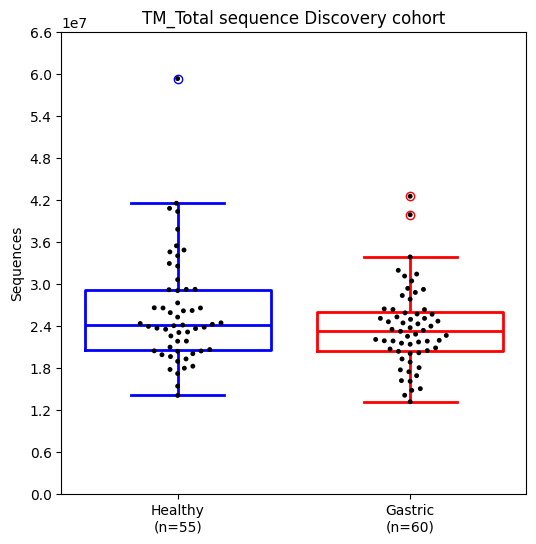

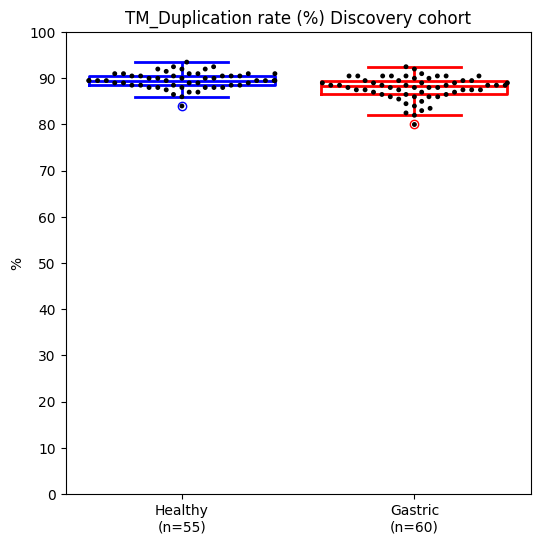

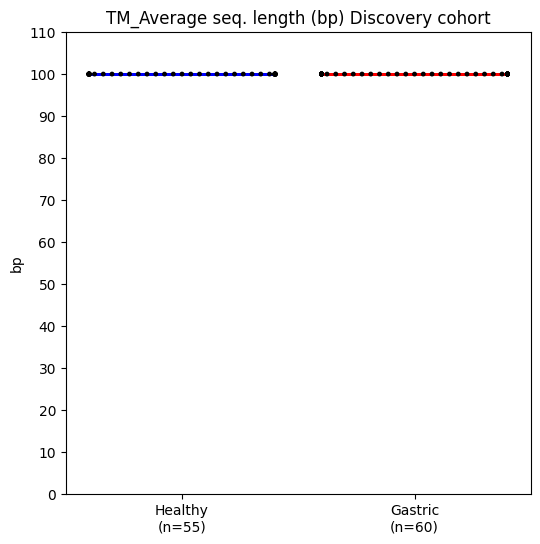

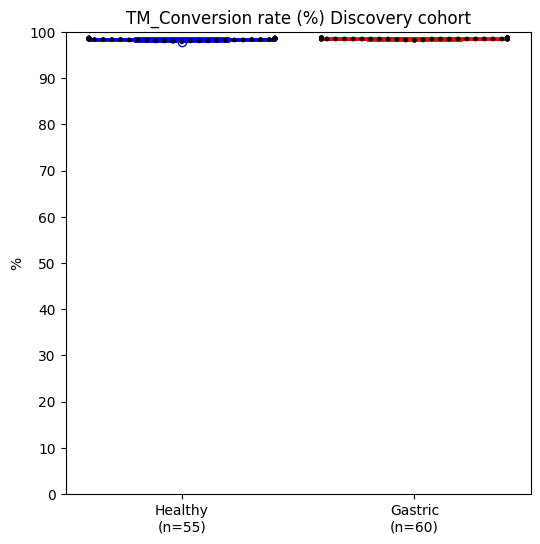

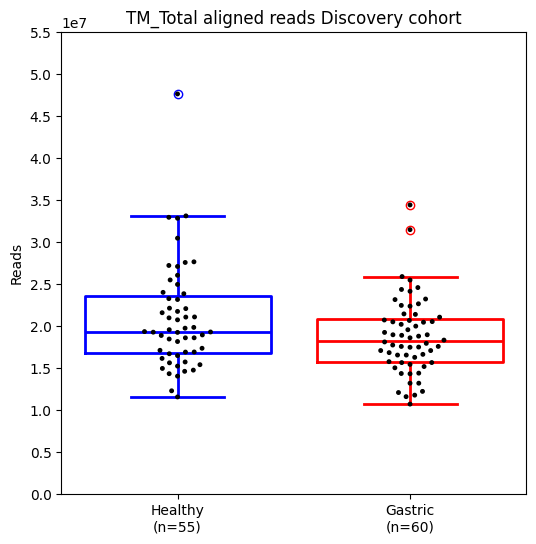

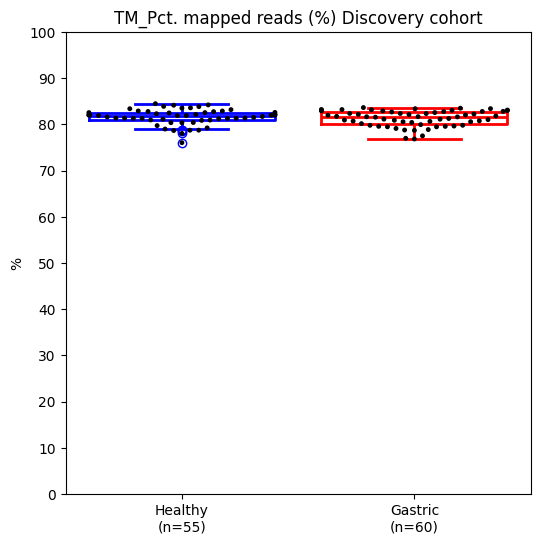

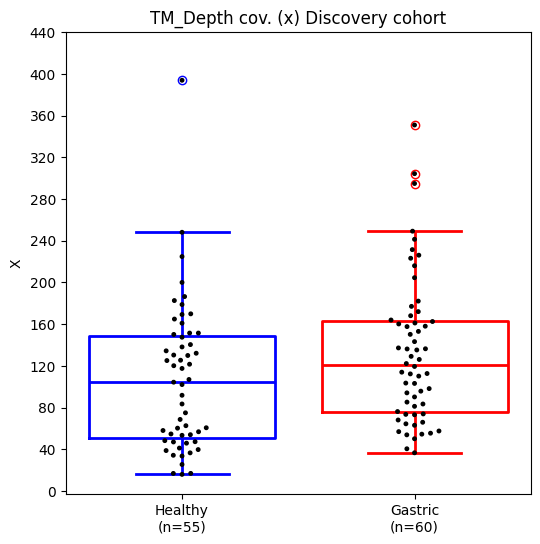

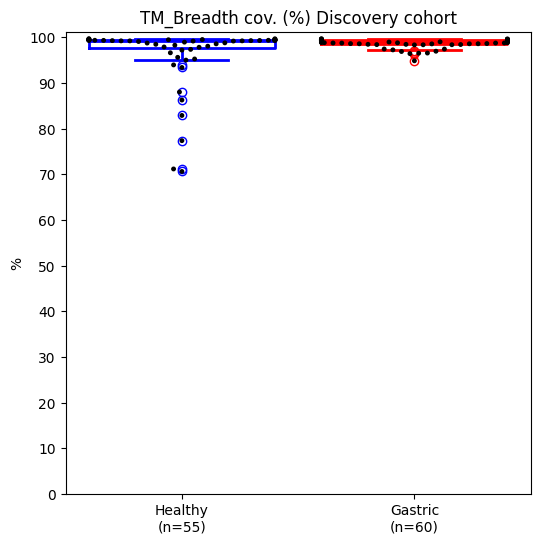

In [20]:
# Các thông số qc seq
# for y in co_horts:
y='Discovery'
df=data_qc[data_qc['Cohort']==y]
# col='Group'
for col in param_seq:
# col='GW_Total sequence'
    if (df[col].dtype!='object') and ('TM' in col or 'GW' in col): 
        if 'sequence' in col:
            ylabel='Sequences'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        elif 'rate' in col or 'Pct' in col or 'Breadth' in col:
            ylabel='%'
            stop=110
            step=10
        elif 'aligned' in col:
            ylabel='Reads'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        elif 'length' in col:
            ylabel='bp'
            stop=120
            step=10
        elif 'TM_Depth' in col:
            ylabel='X'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        elif 'GW_Depth' in col:
            ylabel='X'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1

        plt.figure(figsize=(6,6))
        ax=sb.swarmplot(data=df,x='Label',y=col,order=[0,1],palette=['black'],marker='.',linewidth=1)
        ax=sb.boxplot(data=df,y=col,x='Label',palette=['b','r'],fill=False,linewidth=2,order=[0,1])
        ax.set(xlabel=None)
        # sb.swarmplot(data=df,x='Class',y=col,palette=['b','g','orange','r'],marker='o',linewidth=1,order=[0,1,2,3])
        # sb.boxplot(data=df,y=col,x='Class',palette=['white'],order=[0,1,2,3])
        # plt.xlabel()
        plt.yticks(np.arange(0,stop,step))
        labels=[
            'Healthy\n(n='+str(len(data_qc_Discovery[data_qc_Discovery['Type']=='Healthy']))+')',
            'Gastric\n(n='+str(len(data_qc_Discovery[data_qc_Discovery['Type']=='Gastric']))+')',
        ]
        plt.xticks(ticks=[0,1],labels=labels,fontsize=10)
        plt.ylabel(ylabel)
    
        plt.title(col+' '+y+' cohort')

### Plot age

C:\Users\VODACHO\AppData\Local\Temp\ipykernel_3252\2493892408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
C:\Users\VODACHO\AppData\Local\Temp\ipykernel_3252\2493892408.py:5: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
C:\Users\VODACHO\AppData\Local\Temp\ipykernel_3252\2493892408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='

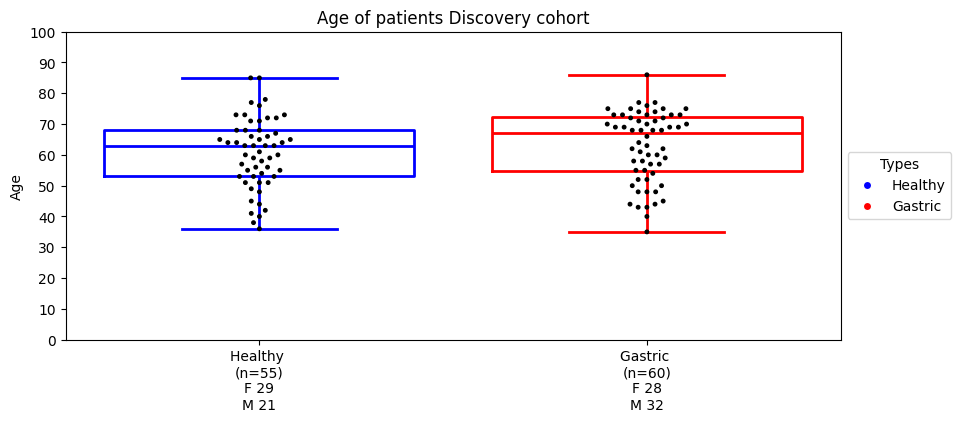

In [21]:
# Plot độ tuổi
for y in ['Discovery']:
# y='Discovery'
    plt.figure(figsize=(10,4))
    sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
    sb.boxplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['b','r'],order=[0,1],fill=False,linewidth=2)
    plt.yticks(np.arange(0,110,10))
    labels_0='Healthy \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)&(data_qc['Gender']=='M')]))
    # labels_1='Gastritis \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='M')]))
    # labels_2='Pre_\ncancerous \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)&(data_qc['Gender']=='M')]))
    labels_3='Gastric \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='M')]))
    plt.xticks(ticks=[0,1],labels=[labels_0,labels_3])
    custom_lines = [
                    Line2D([0], [0],marker='o',color='w', markerfacecolor='blue'),
                    # Line2D([0], [0],marker='o',color='w', markerfacecolor='g'),
                    # Line2D([0], [0],marker='o',color='w', markerfacecolor='orange'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r')
                    ]
    plt.legend(custom_lines,['Healthy','Gastric'],title='Types',loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('')
    plt.title('Age of patients '+y+' cohort')

## Load data_all

In [22]:
# data_all=pd.read_csv(exp_id+'_data_all.csv')
# data_all.index=list(data_all['SampleID'])
# vector=[]
# for s in list(data_all['SampleID']):
#     if s in list(data_qc_Discovery['SampleID']):
#         vector+=[True]
#     else:
#         vector+=[False]
# data_all_Discovery=data_all[vector]
# if 'Run_TM' in data_all_Discovery.columns:
#     data_all_Discovery.drop(labels='Run_TM',axis=1,inplace=True)
# if 'Run_GW' in data_all_Discovery.columns:
#     data_all_Discovery.drop(labels='Run_GW',axis=1,inplace=True)
# data_all_Discovery

In [23]:
list_columns_vlookup=['Cohort','Class','Type','Age','Gender','Run TM',
                    #   'Run GW'
                      ]

In [24]:
col_start=len(list_columns_vlookup)+1
col_start

7

In [ ]:
# #Gán label cho data features
# for col in list_columns_vlookup:
#     lst=[]
#     for s in list(data_all_Discovery['SampleID']):
#         lst+=[data_qc_Discovery[data_qc_Discovery['SampleID']==s][col].reset_index(drop=True)[0]]
#     data_all_Discovery.insert(loc=1,column=col,value=lst)
# data_all_Discovery

,SampleID,Run GW,Run TM,Gender,Age,Type,Class,Cohort,TMD_1,TMD_2,...,MOTIF_END_TTCG,MOTIF_END_TTCT,MOTIF_END_TTGA,MOTIF_END_TTGC,MOTIF_END_TTGG,MOTIF_END_TTGT,MOTIF_END_TTTA,MOTIF_END_TTTC,MOTIF_END_TTTG,MOTIF_END_TTTT
HNGK002,HNGK002,R6110,R6110,F,66,Gastric,4,Discovery,0.947487,0.112098,...,0.000397,0.004737,0.004304,0.002690,0.003608,0.003940,0.006534,0.005295,0.005163,0.009350
HNGK003,HNGK003,R6110,R6110,F,72,Gastric,4,Discovery,0.944010,0.128898,...,0.000371,0.004670,0.004120,0.002563,0.003335,0.003750,0.006373,0.005254,0.004986,0.009124
HNGK004,HNGK004,R6110,R6110,F,69,Gastric,4,Discovery,0.954515,0.096882,...,0.000372,0.004699,0.004164,0.002604,0.003361,0.003824,0.006476,0.005213,0.004956,0.009242
HNGK005,HNGK005,R6124,R6124,M,48,Gastric,4,Discovery,0.943431,0.082683,...,0.000383,0.004600,0.004213,0.002550,0.003434,0.003776,0.006098,0.005041,0.004889,0.008961
HNGK006,HNGK006,R6124,R6124,F,77,Gastric,4,Discovery,0.942895,0.140086,...,0.000376,0.004588,0.003992,0.002548,0.003231,0.003657,0.005999,0.004988,0.004871,0.008746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K0AAAP67,K0AAAP67,R5167,R5167,F,75,Healthy,0,Discovery,0.977778,0.207547,...,0.000369,0.004700,0.004144,0.002634,0.003240,0.003786,0.006427,0.005299,0.004959,0.009281
K0AAAR46,K0AAAR46,R5305,R5305,F,72,Healthy,0,Discovery,1.000000,0.042345,...,0.000360,0.004479,0.004121,0.002548,0.003367,0.003640,0.006408,0.005056,0.004949,0.008800
K0AAAR48,K0AAAR48,R5305,R5305,F,72,Healthy,0,Discovery,0.983146,0.144000,...,0.000396,0.004577,0.004192,0.002654,0.003647,0.003856,0.006060,0.005055,0.005039,0.008884
K0AAAR62,K0AAAR62,R5343,R5343,F,69,Healthy,0,Discovery,0.965616,0.103226,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Features

In [ ]:
#Chia 6 features
# TMD=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('TMD'))],axis=1)
# GWMD=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWMD'))],axis=1)
# CNA=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('CNA'))],axis=1)
# flen=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('flen'))],axis=1)
# MOTIF_END=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('MOTIF_END'))],axis=1)
# GWFP_long=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWFP_long'))],axis=1)
# GWFP_short=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWFP_short'))],axis=1)
# GWFP_total=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWFP_total'))],axis=1)
# GWFP_ratio=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('GWFP_ratio'))],axis=1)
# All_features=pd.concat([data_all_Discovery[['SampleID']+list_columns_vlookup],data_all_Discovery.filter(regex=('TMD|GWMD|CNA|flen|MOTIF_END|GWFP'))],axis=1)



## DEFINE FEA AND PAIR

In [3]:
features=[
        'TMD',
          # 'GWMD','CNA','flen','MOTIF_END','GWFP_long','GWFP_short','GWFP_total','GWFP_ratio',
        #   'MOTIF21',
          'TM_CNA','TM_RATIO_SHORT_LONG','TM_RATIO_SHORT_TOTAL',
          'TM_flen','TM_EM'
        #   'ALL','ALL21',
        #   'ALL21TM',
        #   'CONCAT','CONCAT21',
        #   'CONCAT21TM'
          ]
features

['TMD',
 'TM_CNA',
 'TM_RATIO_SHORT_LONG',
 'TM_RATIO_SHORT_TOTAL',
 'TM_flen',
 'TM_EM']

# Features path

In [4]:
path_f={
    'TMD':"D:\VoDacHo\Gastric\HNG\HNG_TMD.csv",
    'TM_CNA':"D:\VoDacHo\Database\Data\TM_450\TM_CNA.csv",
    'TM_RATIO_SHORT_LONG':"D:\VoDacHo\Database\Data\TM_450\TM_RATIO_SHORT_LONG.csv",
    'TM_RATIO_SHORT_TOTAL':"D:\VoDacHo\Database\Data\TM_450\TM_RATIO_SHORT_TOTAL.csv",
    'TM_flen':"D:\VoDacHo\Database\Data\TM_450\TM_flen1D_3.csv",
    'TM_EM':"D:\VoDacHo\Database\Data\TM_450\TM_EM1D_4.csv"
}

In [10]:
for f in features:
    df=pd.read_csv(path_f[f])
    df=df[df['SampleID'].isin(metadata['SampleID'])]
    print(f, df.shape)
    df.to_csv(exp_id+'_'+f+'.csv',index=False)

TMD (115, 447)
TM_CNA (115, 451)
TM_RATIO_SHORT_LONG (115, 451)
TM_RATIO_SHORT_TOTAL (115, 451)
TM_flen (115, 67951)
TM_EM (115, 115201)


## PAIR

In [28]:
PAIR=[
    # 'Non_cancer vs Cancer',
    # 'Non_cancer vs Gastric',
    # 'Healthy vs Lesion',
    # 'Gastritis vs Cancer',
    # 'Healthy vs Gastritis',
    # 'Healthy vs Precancerous',
    'Healthy vs Gastric',
    # 'Gastritis vs Precancerous',
    # 'Gastritis vs Gastric',
    # 'Precancerous vs Gastric',
    # 'Non_Gastric vs Gastric'
    #   'Healthy vs Colorectal_cancer'
      ]

## Fea

In [108]:
# fea={
#     'TMD':TMD,
#     'GWMD':GWMD,
#     'CNA':CNA,
#     'flen':flen,
#     'MOTIF_END':MOTIF_END,
#     'GWFP_long':GWFP_long,
#     'GWFP_short':GWFP_short,
#     'GWFP_total':GWFP_total,
#     'GWFP_ratio':GWFP_ratio,
#     # 'MOTIF21':MOTIF21
#     }
fea={}
for f in features:
    df=pd.read_csv(path_f[f])
    fea[f]=df[df['SampleID'].isin(list(data_qc_Discovery['SampleID']))]
    for col in list_columns_vlookup:
        lst=[]
        for s in list(fea[f]['SampleID']):
            lst+=[data_qc_Discovery[data_qc_Discovery['SampleID']==s][col].reset_index(drop=True)[0]]
        fea[f].insert(loc=1,column=col,value=lst)
    fea[f].index=list(fea[f]['SampleID'])
    fea[f] = fea[f].replace([np.inf, -np.inf], 0).fillna(0)
    fea[f].sort_index()

KeyError: 'ENT_TM_EM'

In [115]:
for f in features:
    print(f,fea[f].shape)

TMD (115, 453)
TM_CNA (115, 457)
TM_RATIO_SHORT_LONG (115, 457)
TM_RATIO_SHORT_TOTAL (115, 457)
TM_flen (115, 67957)
TM_EM (115, 115207)
ENT_TM_EM (115, 457)
ENT_TM_flen (115, 457)


In [67]:
fea[f]

,SampleID,Run TM,Gender,Age,Type,Class,Cohort,TM_EM_1_TTTT,TM_EM_2_TTTT,TM_EM_3_TTTT,...,TM_EM_442_AAAA,TM_EM_443_AAAA,TM_EM_444_AAAA,TM_EM_445_AAAA,TM_EM_446_AAAA,TM_EM_447_AAAA,TM_EM_448_AAAA,TM_EM_449_AAAA,TM_EM_450_AAAA,TM_EM_451_AAAA
HNGH005,HNGH005,R7820,F,61,Healthy,0,Discovery,0.0,0.0,0.0,...,0.000000,0.027027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HNGH006,HNGH006,R7820,M,66,Healthy,0,Discovery,0.0,0.0,0.0,...,0.037037,0.018868,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HNGH007,HNGH007,R7820,F,48,Healthy,0,Discovery,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HNGH011,HNGH011,R7820,M,53,Healthy,0,Discovery,0.0,0.0,0.0,...,0.038462,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HNGH012,HNGH012,R7820,M,60,Healthy,0,Discovery,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK095,HNGK095,R7870,M,58,Gastric,4,Discovery,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HNGK096,HNGK096,R7870,M,50,Gastric,4,Discovery,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HNGK101,HNGK101,R7870,F,61,Gastric,4,Discovery,0.0,0.0,0.0,...,0.000000,0.028571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HNGK102,HNGK102,R7870,F,68,Gastric,4,Discovery,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Entropy

In [68]:
lst_region={}

In [69]:
for f in ['TM_flen','TM_EM']:
    df=pd.DataFrame(fea[f].columns[col_start:])
    df['Region']=df[0].str.split('_').str[0] + '_' + df[0].str.split('_').str[1] + '_' + df[0].str.split('_').str[2]
    lst=list(df['Region'].drop_duplicates(keep='first'))
    lst_region[f]=lst

In [70]:
lst_region['TM_flen']

['TM_flen_1',
 'TM_flen_2',
 'TM_flen_3',
 'TM_flen_4',
 'TM_flen_5',
 'TM_flen_6',
 'TM_flen_7',
 'TM_flen_8',
 'TM_flen_9',
 'TM_flen_10',
 'TM_flen_11',
 'TM_flen_12',
 'TM_flen_13',
 'TM_flen_14',
 'TM_flen_15',
 'TM_flen_16',
 'TM_flen_17',
 'TM_flen_18',
 'TM_flen_19',
 'TM_flen_20',
 'TM_flen_21',
 'TM_flen_22',
 'TM_flen_23',
 'TM_flen_24',
 'TM_flen_25',
 'TM_flen_26',
 'TM_flen_27',
 'TM_flen_28',
 'TM_flen_29',
 'TM_flen_30',
 'TM_flen_31',
 'TM_flen_32',
 'TM_flen_33',
 'TM_flen_34',
 'TM_flen_35',
 'TM_flen_36',
 'TM_flen_37',
 'TM_flen_38',
 'TM_flen_39',
 'TM_flen_40',
 'TM_flen_41',
 'TM_flen_42',
 'TM_flen_43',
 'TM_flen_44',
 'TM_flen_45',
 'TM_flen_46',
 'TM_flen_47',
 'TM_flen_48',
 'TM_flen_49',
 'TM_flen_50',
 'TM_flen_51',
 'TM_flen_52',
 'TM_flen_53',
 'TM_flen_54',
 'TM_flen_55',
 'TM_flen_56',
 'TM_flen_57',
 'TM_flen_58',
 'TM_flen_59',
 'TM_flen_60',
 'TM_flen_61',
 'TM_flen_62',
 'TM_flen_63',
 'TM_flen_64',
 'TM_flen_65',
 'TM_flen_66',
 'TM_flen_67',
 'TM

In [53]:
lst_region['TM_EM']

['TM_EM_1',
 'TM_EM_2',
 'TM_EM_3',
 'TM_EM_4',
 'TM_EM_5',
 'TM_EM_6',
 'TM_EM_7',
 'TM_EM_8',
 'TM_EM_9',
 'TM_EM_10',
 'TM_EM_11',
 'TM_EM_12',
 'TM_EM_13',
 'TM_EM_14',
 'TM_EM_15',
 'TM_EM_16',
 'TM_EM_17',
 'TM_EM_18',
 'TM_EM_19',
 'TM_EM_20',
 'TM_EM_21',
 'TM_EM_22',
 'TM_EM_23',
 'TM_EM_24',
 'TM_EM_25',
 'TM_EM_26',
 'TM_EM_27',
 'TM_EM_28',
 'TM_EM_29',
 'TM_EM_30',
 'TM_EM_31',
 'TM_EM_32',
 'TM_EM_33',
 'TM_EM_34',
 'TM_EM_35',
 'TM_EM_36',
 'TM_EM_37',
 'TM_EM_38',
 'TM_EM_39',
 'TM_EM_40',
 'TM_EM_41',
 'TM_EM_42',
 'TM_EM_43',
 'TM_EM_44',
 'TM_EM_45',
 'TM_EM_46',
 'TM_EM_47',
 'TM_EM_48',
 'TM_EM_49',
 'TM_EM_50',
 'TM_EM_51',
 'TM_EM_52',
 'TM_EM_53',
 'TM_EM_54',
 'TM_EM_55',
 'TM_EM_56',
 'TM_EM_57',
 'TM_EM_58',
 'TM_EM_59',
 'TM_EM_60',
 'TM_EM_61',
 'TM_EM_62',
 'TM_EM_63',
 'TM_EM_64',
 'TM_EM_65',
 'TM_EM_66',
 'TM_EM_67',
 'TM_EM_68',
 'TM_EM_69',
 'TM_EM_70',
 'TM_EM_71',
 'TM_EM_72',
 'TM_EM_73',
 'TM_EM_74',
 'TM_EM_75',
 'TM_EM_76',
 'TM_EM_77',
 'TM_EM_

In [83]:
f='TM_flen'

In [87]:
result=pd.DataFrame()
for region in lst_region[f]:
    df = fea[f].filter(regex=r'^('+region+')')
    value=[entropy(df.loc[s,:]) for s in list(df.index)]
    df.insert(loc=0, column=region, value=value)
    result=pd.concat([result,df[[region]]],axis=1)
    result = result.replace([np.inf, -np.inf], 0).fillna(0)
result.insert(loc=0,column='SampleID',value=list(result.index))

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACH

In [88]:
result

,SampleID,TM_flen_1,TM_flen_2,TM_flen_3,TM_flen_4,TM_flen_5,TM_flen_6,TM_flen_7,TM_flen_8,TM_flen_9,...,TM_flen_442,TM_flen_443,TM_flen_444,TM_flen_445,TM_flen_446,TM_flen_447,TM_flen_448,TM_flen_449,TM_flen_450,TM_flen_451
HNGH005,HNGH005,8.284425,8.303378,8.295684,7.696853,5.975616,6.142612,5.624191,6.130257,5.892672,...,4.111734,4.054651,3.545288,3.522247,3.784846,2.921658,3.778212,3.511640,3.128808,3.384402
HNGH006,HNGH006,8.194710,8.209518,8.226133,7.656070,5.992547,5.998748,5.628341,6.053097,5.812651,...,3.748026,3.904183,3.699041,3.131506,3.636969,2.704781,3.733968,3.705149,2.910807,3.092161
HNGH007,HNGH007,8.196781,8.275640,8.261585,7.670460,6.089470,6.038403,5.687202,6.074801,5.896633,...,3.936481,3.827563,3.671588,3.415431,3.360051,2.754332,3.982299,3.816860,3.380778,2.792440
HNGH011,HNGH011,7.674496,7.726089,7.696096,7.116320,5.368635,5.633298,5.075195,5.526916,5.190225,...,3.698864,3.400692,3.451816,2.589603,3.119071,2.505290,3.388706,3.011846,2.831544,3.143541
HNGH012,HNGH012,7.615499,7.649555,7.627324,6.850646,5.348481,5.376979,4.828153,5.334860,5.306735,...,3.327491,3.420166,3.191150,2.692291,2.666626,1.351784,3.337225,2.262386,2.523922,1.557113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK095,HNGK095,7.347307,7.372326,7.484695,6.728646,5.115776,4.961053,4.752288,5.106203,5.097640,...,2.947005,3.623182,2.745854,1.893788,2.532758,1.991509,2.577018,2.658193,2.833739,1.711845
HNGK096,HNGK096,7.245824,7.272253,7.291272,6.595265,4.868111,4.995263,4.846176,5.174280,5.219211,...,2.351937,3.336109,2.778225,0.693147,3.081103,2.479122,2.727810,2.245952,1.320888,1.515708
HNGK101,HNGK101,8.051042,8.118644,8.148681,7.423357,5.877201,5.830635,5.290643,5.983827,5.572289,...,3.735784,3.613214,3.835604,3.131085,3.539976,3.034765,3.769320,3.510534,3.265865,3.346389
HNGK102,HNGK102,8.321879,8.383420,8.336992,7.691703,6.193029,6.167727,5.737499,6.118293,6.013708,...,4.094330,3.981699,3.872225,3.381065,3.609792,3.343096,3.898214,3.601883,3.680404,3.409710


In [89]:
result.to_csv('HNG_ENT_'+f+'.csv',index=False)


In [90]:
f='TM_EM'
result=pd.DataFrame()
for region in lst_region[f]:
    df = fea[f].filter(regex=r'^('+region+')')
    value=[entropy(df.loc[s,:]) for s in list(df.index)]
    df.insert(loc=0, column=region, value=value)
    result=pd.concat([result,df[[region]]],axis=1)
    result = result.replace([np.inf, -np.inf], 0).fillna(0)
result.insert(loc=0,column='SampleID',value=list(result.index))
result.to_csv('HNG_ENT_'+f+'.csv',index=False)

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)
C:\Users\VODACH

In [91]:
result

,SampleID,TM_EM_1,TM_EM_2,TM_EM_3,TM_EM_4,TM_EM_5,TM_EM_6,TM_EM_7,TM_EM_8,TM_EM_9,...,TM_EM_442,TM_EM_443,TM_EM_444,TM_EM_445,TM_EM_446,TM_EM_447,TM_EM_448,TM_EM_449,TM_EM_450,TM_EM_451
HNGH005,HNGH005,7.874163,7.891636,7.978073,7.296969,5.720162,5.826817,5.076571,5.694993,5.304217,...,3.372052,3.534289,3.461310,2.740890,3.583696,2.479956,3.586915,3.069946,3.087042,2.563151
HNGH006,HNGH006,7.741995,7.828329,7.884183,7.249386,5.613951,5.635535,5.348613,5.622589,5.333974,...,3.385438,3.456523,3.383739,2.588573,3.374314,2.588573,3.416182,3.232776,2.890372,2.668079
HNGH007,HNGH007,7.778366,7.908486,7.937470,7.277855,5.701029,5.783548,5.161170,5.651403,5.480261,...,3.788265,3.419753,3.528581,2.984870,3.065965,1.666333,3.661372,3.392615,3.328472,2.094729
HNGH011,HNGH011,7.161838,7.205460,7.223063,6.572788,4.884518,5.158031,4.499314,4.962152,4.645896,...,2.737976,2.912494,2.871476,1.560710,2.954673,2.397895,2.886165,2.622996,1.945910,2.166085
HNGH012,HNGH012,7.025703,7.097929,7.122024,6.329782,4.926999,4.725161,4.205528,4.709703,4.734071,...,2.725550,2.971377,2.917048,2.098274,2.025326,1.386294,2.852105,1.889159,2.351673,1.609438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK095,HNGK095,6.922481,6.942952,7.045334,6.351638,4.886178,4.484962,4.146795,4.573666,4.686729,...,2.484907,3.282895,2.458311,1.386294,2.397895,2.043192,2.512659,1.906155,1.906155,1.906155
HNGK096,HNGK096,6.778144,6.845111,6.874194,6.154682,4.613663,4.632337,4.388053,4.492613,4.711269,...,2.253858,2.268535,1.791759,1.098612,2.809783,2.163956,2.369382,2.079442,1.386294,1.039721
HNGK101,HNGK101,7.731460,7.763606,7.854931,7.085834,5.569518,5.731118,4.884460,5.540369,5.271826,...,3.201876,3.302748,3.420939,2.751667,3.212991,2.582306,3.716799,3.363267,3.151459,2.771170
HNGK102,HNGK102,8.015845,8.111974,8.110480,7.372554,5.876840,5.886984,5.454632,5.679389,5.660016,...,3.769701,3.808826,3.490580,3.052521,3.473803,3.141804,3.800867,3.430313,3.476131,2.871476


# LOAD DATA 2

In [111]:
features=features+['ENT_TM_EM','ENT_TM_flen']
features

['TMD',
 'TM_CNA',
 'TM_RATIO_SHORT_LONG',
 'TM_RATIO_SHORT_TOTAL',
 'TM_flen',
 'TM_EM',
 'ENT_TM_EM',
 'ENT_TM_flen']

In [112]:
path_f['ENT_TM_EM']="D:\VoDacHo\Gastric\HNG\HNG_ENT_TM_EM.csv"
path_f['ENT_TM_flen']="D:\VoDacHo\Gastric\HNG\HNG_ENT_TM_flen.csv"

In [113]:
for f in ['ENT_TM_EM','ENT_TM_flen']:
    df=pd.read_csv(path_f[f])
    cols=[]
    for c in df.columns:
        if 'TM_EM' in c or 'TM_flen' in c:
            cols+=['ENT_'+c]
        else:
            cols+=[c]
    df.columns=cols
    fea[f]=df[df['SampleID'].isin(list(data_qc_Discovery['SampleID']))]
    for col in list_columns_vlookup:
        lst=[]
        for s in list(fea[f]['SampleID']):
            lst+=[data_qc_Discovery[data_qc_Discovery['SampleID']==s][col].reset_index(drop=True)[0]]
        fea[f].insert(loc=1,column=col,value=lst)
    fea[f].index=list(fea[f]['SampleID'])
    fea[f] = fea[f].replace([np.inf, -np.inf], 0).fillna(0)
    fea[f].sort_index()
    
    

In [114]:
fea[f]

,SampleID,Run TM,Gender,Age,Type,Class,Cohort,ENT_TM_flen_1,ENT_TM_flen_2,ENT_TM_flen_3,...,ENT_TM_flen_442,ENT_TM_flen_443,ENT_TM_flen_444,ENT_TM_flen_445,ENT_TM_flen_446,ENT_TM_flen_447,ENT_TM_flen_448,ENT_TM_flen_449,ENT_TM_flen_450,ENT_TM_flen_451
HNGH005,HNGH005,R7820,F,61,Healthy,0,Discovery,8.284425,8.303378,8.295684,...,4.111734,4.054651,3.545288,3.522247,3.784846,2.921658,3.778212,3.511640,3.128808,3.384402
HNGH006,HNGH006,R7820,M,66,Healthy,0,Discovery,8.194710,8.209518,8.226133,...,3.748026,3.904183,3.699041,3.131506,3.636969,2.704781,3.733968,3.705149,2.910807,3.092161
HNGH007,HNGH007,R7820,F,48,Healthy,0,Discovery,8.196781,8.275640,8.261585,...,3.936481,3.827563,3.671588,3.415431,3.360051,2.754332,3.982299,3.816860,3.380778,2.792440
HNGH011,HNGH011,R7820,M,53,Healthy,0,Discovery,7.674496,7.726089,7.696096,...,3.698864,3.400692,3.451816,2.589603,3.119071,2.505290,3.388706,3.011846,2.831544,3.143541
HNGH012,HNGH012,R7820,M,60,Healthy,0,Discovery,7.615499,7.649555,7.627324,...,3.327491,3.420166,3.191150,2.692291,2.666626,1.351784,3.337225,2.262386,2.523922,1.557113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK095,HNGK095,R7870,M,58,Gastric,4,Discovery,7.347307,7.372326,7.484695,...,2.947005,3.623182,2.745854,1.893788,2.532758,1.991509,2.577018,2.658193,2.833739,1.711845
HNGK096,HNGK096,R7870,M,50,Gastric,4,Discovery,7.245824,7.272253,7.291272,...,2.351937,3.336109,2.778225,0.693147,3.081103,2.479122,2.727810,2.245952,1.320888,1.515708
HNGK101,HNGK101,R7870,F,61,Gastric,4,Discovery,8.051042,8.118644,8.148681,...,3.735784,3.613214,3.835604,3.131085,3.539976,3.034765,3.769320,3.510534,3.265865,3.346389
HNGK102,HNGK102,R7870,F,68,Gastric,4,Discovery,8.321879,8.383420,8.336992,...,4.094330,3.981699,3.872225,3.381065,3.609792,3.343096,3.898214,3.601883,3.680404,3.409710


In [104]:
fea[f].iloc[:,col_start:]

,Run_TM,TMD_1,TMD_2,TMD_3,TMD_4,TMD_5,TMD_6,TMD_7,TMD_8,TMD_9,...,TMD_442,TMD_443,TMD_444,TMD_445,TMD_446,TMD_447,TMD_448,TMD_449,TMD_450,TMD_451
HNGH005,R7820,96.3283,5.87302,3.85627,7.52688,95.7871,93.4132,94.6429,28.40000,14.05840,...,2.556300,10.85410,2.95749,8.03324,3.52941,0.00000,93.5154,2.60736,36.1702,0.224719
HNGH006,R7820,92.8389,13.31920,5.59846,5.67742,95.3237,97.2973,91.6667,12.15280,20.49470,...,4.351690,3.69030,8.57143,12.99300,8.40580,3.22581,91.5663,5.76132,30.5263,1.827680
HNGH007,R7820,96.1606,12.03160,6.29085,8.17271,95.1807,94.3750,96.8254,30.87250,17.29860,...,0.965600,2.81924,2.73224,6.82148,2.02020,4.76190,92.1466,3.55221,39.4904,0.714286
HNGH011,R7820,96.8254,11.76470,3.59551,11.94490,91.2371,88.4058,100.0000,9.95475,12.03320,...,5.201700,3.70370,7.28477,22.13740,5.68720,0.00000,84.5161,1.35870,38.0952,1.416430
HNGH012,R7820,96.9072,12.35290,2.34375,6.36161,92.5926,100.0000,89.6552,6.87023,16.99350,...,0.865052,12.52010,5.33981,9.44444,7.25806,0.00000,83.1633,8.12500,45.3125,1.351350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK095,R7870,93.9759,8.92857,12.31880,11.48830,97.2477,91.6667,100.0000,17.46030,8.50000,...,4.834610,2.79395,8.33333,6.97674,0.00000,12.50000,88.7097,5.42986,54.6875,2.020200
HNGK096,R7870,97.5610,8.47458,3.64583,20.78240,99.0196,96.7742,100.0000,26.25700,7.01754,...,14.730900,4.23892,3.89610,21.25000,2.04082,0.00000,87.6923,8.33333,33.3333,0.000000
HNGK101,R7870,97.9058,13.63640,5.18518,11.00630,92.7711,90.0000,87.2727,22.25810,26.05360,...,7.519450,3.15917,3.96825,7.76119,3.97351,13.33330,89.2442,4.15282,33.8710,1.578950
HNGK102,R7870,94.8641,13.25300,6.27279,10.75030,93.7365,89.6970,85.3333,28.69760,11.15970,...,2.133630,2.17234,5.69948,9.66057,3.93701,0.00000,90.0000,2.02020,36.5000,1.179250


## Group adjusted p-value

In [118]:
TM_id=[str(n) for n in np.arange(1,375,1)]+[str(n) for n in np.arange(376,452,1)]
groups_padj={}
for f in features:
    if f == 'TM_EM':
        groups_padj[f]=['TM_EM_'+i+'_' for i in TM_id]
    elif f == 'TM_flen':
        groups_padj[f]=['TM_flen_'+i+'_' for i in TM_id]
    # elif f == 'Region_depth':
    #     groups_padj[f]=['TMD']
    elif f == 'TM_flen_entropy':
        groups_padj[f]=['TM_flen']
    elif f == 'TM_EM_entropy':
        groups_padj[f]=['TM_EM']    
    else:
        groups_padj[f]=[f]

# ANALYSIS

## Statistic

In [101]:
col_start

7

In [117]:
#!!!! Chỉ chạy 1 lần xong khóa code lại 
stats_fea={}
for f in features:
    # if f not in ['CONCAT','CONCAT21','CONCAT21TM']:
    print(f)
    stats_fea[f]=STATS_features(fea[f],PAIR,col_start=col_start,groups_PADJ=groups_padj[f])
    print('done')

TMD
done
TM_CNA
done
TM_RATIO_SHORT_LONG
done
TM_RATIO_SHORT_TOTAL
done
TM_flen
done
TM_EM
done
ENT_TM_EM


KeyError: 'ENT_TM_EM'

In [ ]:
# # !!!! Chỉ chạy 1 lần xong khóa code lại 
# with pd.ExcelWriter(exp_id+'_STATS.xlsx') as writer:
#     for f in features:
#         # if f not in ['CONCAT','CONCAT21','CONCAT21TM']:
#             stats_fea[f].to_excel(writer,sheet_name=f,index=False)

In [ ]:
stats_fea={}
for f in features:
    stats_fea[f]=pd.read_excel(exp_id+'_STATS.xlsx',sheet_name=f)

In [122]:
Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[df['PADJ of '+p]<0.05])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,TMD,TM_CNA,TM_RATIO_SHORT_LONG,TM_RATIO_SHORT_TOTAL,TM_flen,TM_EM,ENT_TM_EM,ENT_TM_flen
0,Healthy vs Gastric,51,162,0,0,18,3,145,128


In [124]:
Thong_ke_stats_split.to_clipboard()

# TMD

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


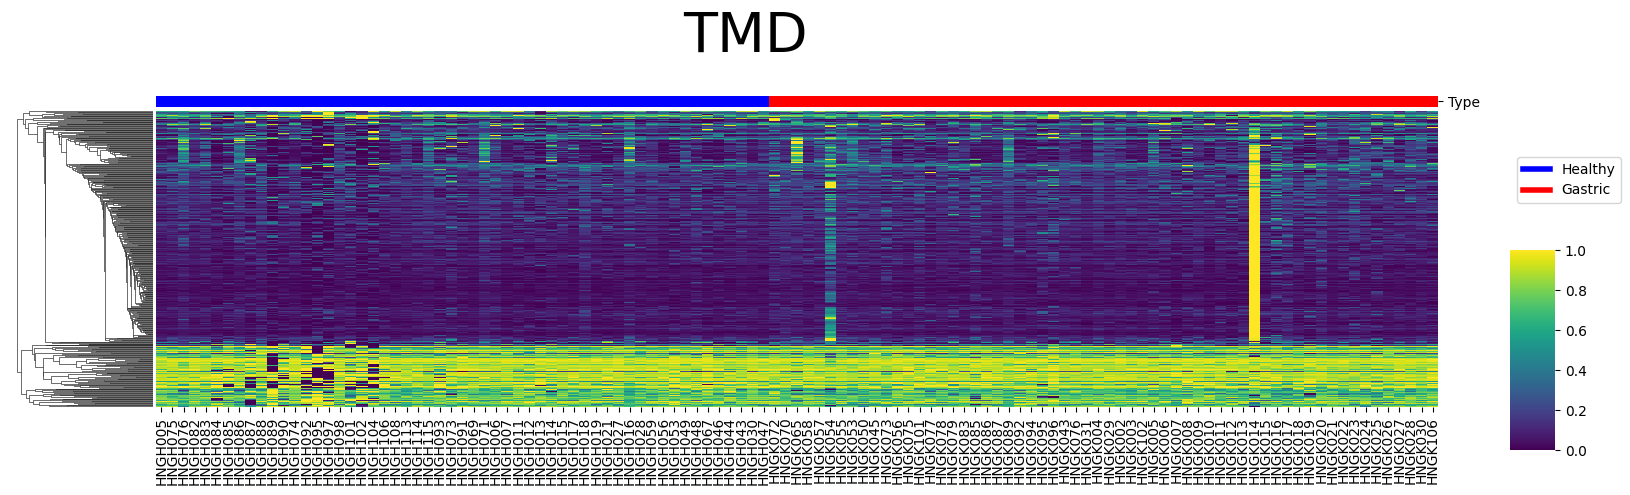

In [125]:
heatmapfea('TMD')

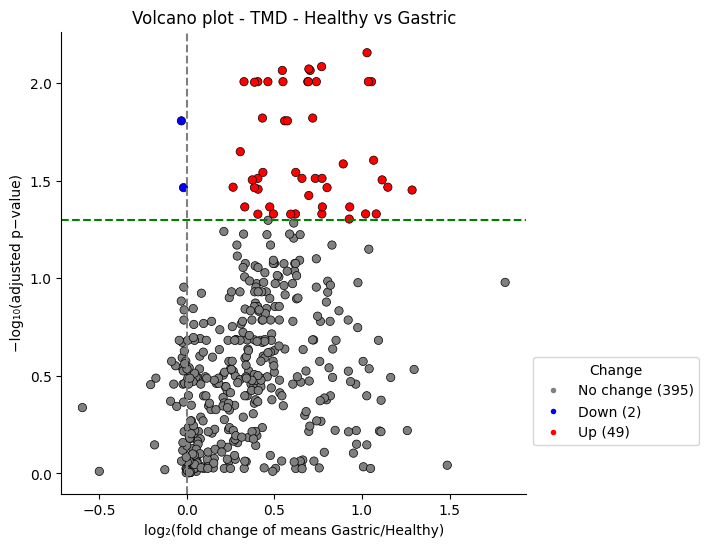

In [126]:
volcanofea('TMD',pair=['Healthy vs Gastric'])

In [164]:
# f='ENT_TM_EM'
f='TMD'
top=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<0.05].sort_values(by='Log2FC of '+p).reset_index(drop=True)['FEATURES'][0:5])+list(stats_fea[f][stats_fea[f]['PADJ of '+p]<0.05].sort_values(by='Log2FC of '+p,ascending=False).reset_index(drop=True)['FEATURES'][0:5])
plot1=fea[f][['Class']+top[0:2]].melt(id_vars="Class")
plot1['x']=plot1.apply(lambda r: r['variable'][4:]+'_'+str(r['Class']),axis=1)
plot1.sort_values(by='x',inplace=True)
plot2=fea[f][['Class']+top[5:10]].melt(id_vars="Class")

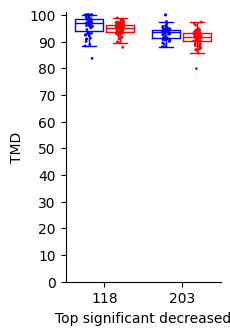

In [172]:
plt.figure(figsize=(2,3.5))
sb.boxplot(data=plot1,y='value',x='variable',hue='Class',
           palette=['b','r'],hue_order=[0,4],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=plot1,y='value',x='variable',hue='Class',
             palette=['b','r'],hue_order=[0,4],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
plt.yticks(np.arange(0,110,10))
plt.xticks(ticks=[0,1],labels=[em.split('_')[1] for em in list(plot1['variable'].unique())])
plt.ylabel('TMD')
plt.xlabel('Top significant decreased')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p-value < 0.00001','Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.3, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.05, .1),loc='center right',frameon=False)

# plt.text(x=0,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=1,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=2,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=3,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=4,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.007,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_1.png',dpi=600,bbox_inches='tight')

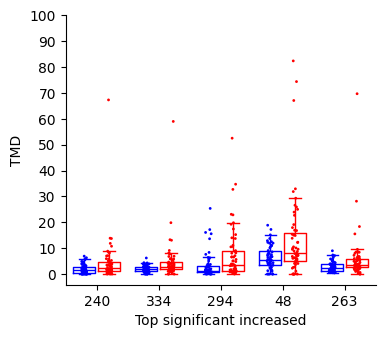

In [173]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=plot2,y='value',x='variable',hue='Class',
           palette=['b','r'],hue_order=[0,4],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=plot2,y='value',x='variable',hue='Class',
             palette=['b','r'],hue_order=[0,4],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
plt.yticks(np.arange(0,110,10))
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(plot2['variable'].unique())])
plt.ylabel('TMD')
plt.xlabel('Top significant increased')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
# plt.text(x=0,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=1,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=2,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=3,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=4,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
# plt.text(x=-1.1,y=-0.0015,s='*****  p-value ')

# ENT

In [152]:
# f='ENT_TM_EM'
f='ENT_TM_flen'

In [153]:
EM_top=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<0.05].sort_values(by='Log2FC of '+p).reset_index(drop=True)['FEATURES'][0:5])+list(stats_fea[f][stats_fea[f]['PADJ of '+p]<0.05].sort_values(by='Log2FC of '+p,ascending=False).reset_index(drop=True)['FEATURES'][0:5])
EM_top

['ENT_TM_flen_175',
 'ENT_TM_flen_113',
 'ENT_TM_flen_95',
 'ENT_TM_flen_392',
 'ENT_TM_flen_112',
 'ENT_TM_flen_76',
 'ENT_TM_flen_432',
 'ENT_TM_flen_394',
 'ENT_TM_flen_315',
 'ENT_TM_flen_219']

In [154]:
EM_plot1=fea[f][['Class']+EM_top[0:5]].melt(id_vars="Class")
EM_plot1['x']=EM_plot1.apply(lambda r: r['variable'][4:]+'_'+str(r['Class']),axis=1)
EM_plot1.sort_values(by='x',inplace=True)
EM_plot1

,Class,variable,value,x
487,0,ENT_TM_flen_112,3.173671,TM_flen_112_0
488,0,ENT_TM_flen_112,2.516410,TM_flen_112_0
489,0,ENT_TM_flen_112,2.253858,TM_flen_112_0
490,0,ENT_TM_flen_112,2.766500,TM_flen_112_0
491,0,ENT_TM_flen_112,3.209557,TM_flen_112_0
...,...,...,...,...
313,4,ENT_TM_flen_95,2.253858,TM_flen_95_4
314,4,ENT_TM_flen_95,1.559581,TM_flen_95_4
315,4,ENT_TM_flen_95,1.907284,TM_flen_95_4
289,4,ENT_TM_flen_95,2.046739,TM_flen_95_4


In [155]:
EM_plot2=fea[f][['Class']+EM_top[5:10]].melt(id_vars="Class")
EM_plot2

,Class,variable,value
0,0,ENT_TM_flen_76,2.079442
1,0,ENT_TM_flen_76,2.499065
2,0,ENT_TM_flen_76,2.818806
3,0,ENT_TM_flen_76,1.559581
4,0,ENT_TM_flen_76,1.351784
...,...,...,...
570,4,ENT_TM_flen_219,1.560710
571,4,ENT_TM_flen_219,1.549826
572,4,ENT_TM_flen_219,2.652588
573,4,ENT_TM_flen_219,2.864739


In [156]:
EM_plot1['variable'].unique()

array(['ENT_TM_flen_112', 'ENT_TM_flen_113', 'ENT_TM_flen_175',
       'ENT_TM_flen_392', 'ENT_TM_flen_95'], dtype=object)

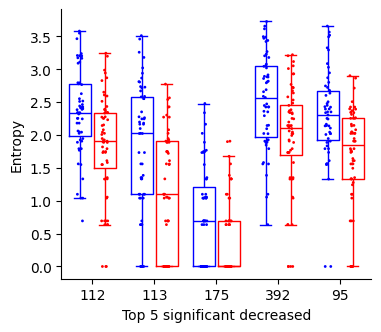

In [157]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot1,y='value',x='variable',hue='Class',
           palette=['b','r'],hue_order=[0,4],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot1,y='value',x='variable',hue='Class',
             palette=['b','r'],hue_order=[0,4],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
# plt.yticks(np.arange(0,0.012,0.002))
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[3] for em in list(EM_plot1['variable'].unique())])
plt.ylabel('Entropy')
plt.xlabel('Top 5 significant decreased')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p-value < 0.00001','Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.3, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.05, .1),loc='center right',frameon=False)

# plt.text(x=0,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=1,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=2,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=3,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=4,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.007,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_1.png',dpi=600,bbox_inches='tight')

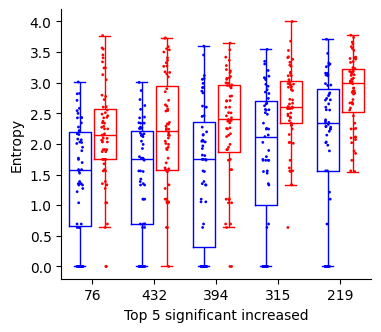

In [158]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Class',
           palette=['b','r'],hue_order=[0,4],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Class',
             palette=['b','r'],hue_order=[0,4],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
# plt.yticks(np.arange(0,0.0035,0.0005))
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[3] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Entropy')
plt.xlabel('Top 5 significant increased')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
# plt.text(x=0,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=1,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=2,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=3,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=4,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
# plt.text(x=-1.1,y=-0.0015,s='*****  p-value ')

# Venn

In [185]:
set0=stats_fea['TMD'][stats_fea['TMD']['PADJ of Healthy vs Gastric']<0.05]
set0=set(set0['FEATURES'].str.split('_').str[1])
print(len(set0))
set0

51


{'105',
 '114',
 '118',
 '121',
 '126',
 '130',
 '135',
 '142',
 '15',
 '162',
 '165',
 '186',
 '2',
 '203',
 '207',
 '212',
 '226',
 '240',
 '247',
 '256',
 '259',
 '263',
 '294',
 '309',
 '313',
 '325',
 '326',
 '334',
 '338',
 '349',
 '36',
 '360',
 '364',
 '373',
 '377',
 '38',
 '39',
 '399',
 '40',
 '409',
 '412',
 '428',
 '43',
 '434',
 '48',
 '57',
 '61',
 '62',
 '63',
 '88',
 '91'}

In [186]:
set1=stats_fea['TM_CNA'][stats_fea['TM_CNA']['PADJ of Healthy vs Gastric']<0.05]
set1=set(set1['FEATURES'].str.split('_').str[2])
print(len(set1))
set1

162


{'100',
 '101',
 '104',
 '106',
 '108',
 '110',
 '112',
 '113',
 '115',
 '116',
 '119',
 '12',
 '120',
 '122',
 '131',
 '135',
 '136',
 '139',
 '140',
 '143',
 '146',
 '149',
 '150',
 '153',
 '154',
 '159',
 '173',
 '176',
 '18',
 '182',
 '185',
 '186',
 '188',
 '191',
 '192',
 '193',
 '194',
 '195',
 '198',
 '199',
 '200',
 '203',
 '204',
 '206',
 '218',
 '221',
 '228',
 '232',
 '233',
 '234',
 '248',
 '251',
 '253',
 '257',
 '258',
 '260',
 '266',
 '267',
 '268',
 '27',
 '274',
 '275',
 '276',
 '278',
 '288',
 '29',
 '293',
 '294',
 '295',
 '296',
 '297',
 '298',
 '299',
 '300',
 '301',
 '303',
 '306',
 '308',
 '310',
 '314',
 '316',
 '317',
 '318',
 '319',
 '32',
 '320',
 '324',
 '325',
 '327',
 '329',
 '33',
 '330',
 '331',
 '333',
 '335',
 '336',
 '338',
 '339',
 '341',
 '343',
 '347',
 '351',
 '353',
 '354',
 '356',
 '362',
 '364',
 '365',
 '366',
 '367',
 '368',
 '369',
 '370',
 '373',
 '374',
 '376',
 '38',
 '380',
 '384',
 '385',
 '386',
 '389',
 '390',
 '391',
 '392',
 '4',
 

In [187]:
set2=stats_fea['ENT_TM_EM'][stats_fea['ENT_TM_EM']['PADJ of Healthy vs Gastric']<0.05]
set2=set(set2['FEATURES'].str.split('_').str[3])
print(len(set2))
set2

145


{'108',
 '109',
 '110',
 '111',
 '113',
 '115',
 '116',
 '117',
 '118',
 '126',
 '129',
 '136',
 '138',
 '139',
 '140',
 '144',
 '145',
 '146',
 '149',
 '150',
 '157',
 '16',
 '163',
 '164',
 '168',
 '169',
 '170',
 '173',
 '176',
 '177',
 '183',
 '185',
 '186',
 '191',
 '192',
 '196',
 '198',
 '199',
 '200',
 '203',
 '205',
 '21',
 '213',
 '214',
 '215',
 '216',
 '218',
 '219',
 '220',
 '222',
 '224',
 '227',
 '228',
 '229',
 '230',
 '232',
 '233',
 '234',
 '237',
 '243',
 '244',
 '250',
 '260',
 '267',
 '271',
 '276',
 '281',
 '282',
 '285',
 '288',
 '291',
 '292',
 '301',
 '302',
 '306',
 '314',
 '315',
 '319',
 '320',
 '324',
 '329',
 '330',
 '333',
 '341',
 '342',
 '344',
 '345',
 '356',
 '359',
 '362',
 '365',
 '368',
 '37',
 '371',
 '372',
 '373',
 '374',
 '376',
 '377',
 '378',
 '384',
 '385',
 '389',
 '390',
 '392',
 '394',
 '395',
 '398',
 '400',
 '404',
 '409',
 '411',
 '413',
 '414',
 '416',
 '420',
 '423',
 '432',
 '433',
 '435',
 '439',
 '444',
 '446',
 '447',
 '449',
 '4

In [188]:
set3=stats_fea['ENT_TM_flen'][stats_fea['ENT_TM_flen']['PADJ of Healthy vs Gastric']<0.05]
set3=set(set3['FEATURES'].str.split('_').str[3])
print(len(set3))
set3

128


{'108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '115',
 '117',
 '129',
 '136',
 '139',
 '140',
 '141',
 '144',
 '145',
 '150',
 '151',
 '157',
 '168',
 '170',
 '175',
 '176',
 '177',
 '185',
 '186',
 '188',
 '191',
 '192',
 '193',
 '196',
 '199',
 '200',
 '205',
 '21',
 '213',
 '215',
 '218',
 '219',
 '222',
 '223',
 '224',
 '227',
 '229',
 '230',
 '232',
 '233',
 '237',
 '244',
 '260',
 '266',
 '267',
 '270',
 '271',
 '276',
 '281',
 '283',
 '285',
 '286',
 '287',
 '292',
 '301',
 '302',
 '306',
 '314',
 '315',
 '320',
 '324',
 '329',
 '333',
 '343',
 '344',
 '356',
 '362',
 '365',
 '366',
 '368',
 '37',
 '370',
 '372',
 '373',
 '374',
 '376',
 '377',
 '378',
 '379',
 '384',
 '390',
 '392',
 '394',
 '395',
 '398',
 '404',
 '411',
 '413',
 '414',
 '416',
 '420',
 '423',
 '432',
 '433',
 '435',
 '439',
 '444',
 '446',
 '447',
 '45',
 '450',
 '46',
 '49',
 '5',
 '53',
 '54',
 '55',
 '56',
 '59',
 '65',
 '68',
 '70',
 '71',
 '76',
 '82',
 '83',
 '84',
 '85',
 '88',
 '92',
 '95',
 '97'}

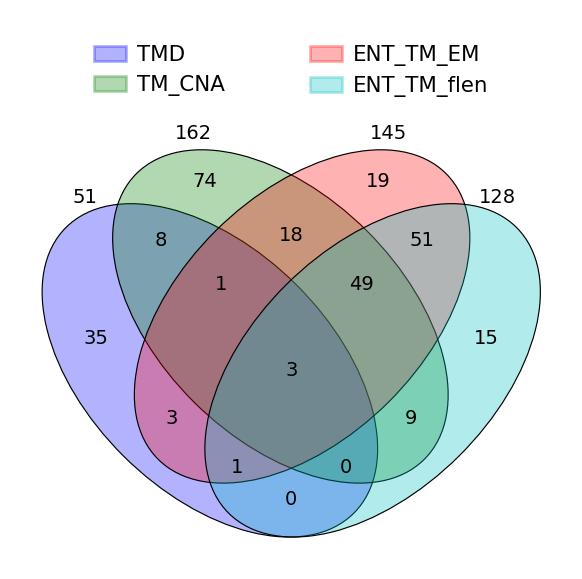

In [190]:
venny4py(sets={'TMD':set0,
               'TM_CNA':set1,
               'ENT_TM_EM':set2,
               'ENT_TM_flen':set3})

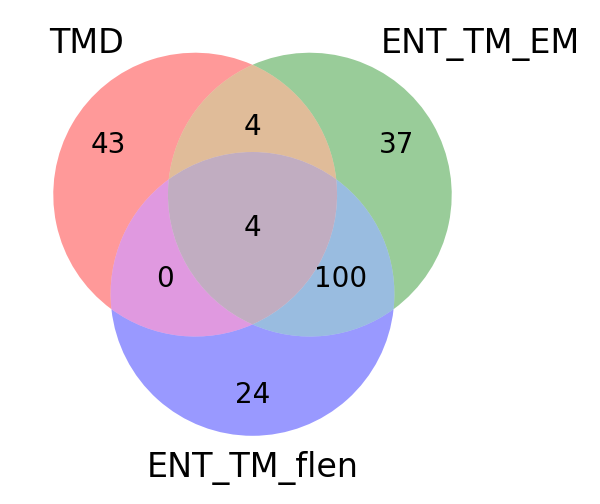

In [193]:
plt.figure(figsize=(3,3))
matplotlib_venn.venn3_unweighted([set0,set2,set3],['TMD','ENT_TM_EM','ENT_TM_flen'])

In [194]:
set0&set2&set3

{'186', '373', '377', '88'}

In [195]:
c=pd.read_csv('D:\VoDacHo\Database\Metadata/TMD_feature_name 1.csv')
c

,chrom,feature_name,CHR,start,end,gene
0,chr1,TMD_1,1,1163599,1163832,C1orf159_TTLL10
1,chr1,TMD_2,1,2443865,2444245,PEX10_PLCH2
2,chr1,TMD_3,1,2789325,2789609,ACTRT2_MMEL1
3,chr1,TMD_4,1,2789723,2790126,ACTRT2_MMEL1
4,chr1,TMD_5,1,6064999,6065249,KCNAB2_CHD5
...,...,...,...,...,...,...
445,chr22,TMD_286,22,27799853,27800150,MN1
446,chr22,TMD_287,22,46007845,46008261,PPARA_WNT7B
447,chr22,TMD_288,22,46525740,46525932,CELSR1_TRMU
448,chr22,TMD_289,22,50548840,50549077,TYMP_SYCE3


In [205]:
lst=list(set0&set2&set3)
lst1 = ["TMD_" + str(x) for x in lst]
lst1

['TMD_377', 'TMD_186', 'TMD_88', 'TMD_373']

In [207]:
df=c[c['feature_name'].isin(lst1)]
df

,chrom,feature_name,CHR,start,end,gene
179,chr6,TMD_373,6,163396939,163397210,PARK2_QKI
181,chr7,TMD_377,7,351427,351579,PDGFA_FAM20C
300,chr11,TMD_88,11,62444331,62444643,SCGB1A1_AHNAK
397,chr17,TMD_186,17,58328520,58328675,BZRAP1


In [209]:
df.to_clipboard()